In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.lines as mlines
from sklearn.preprocessing import scale, minmax_scale
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor, DistanceMatrix
from skbio.stats.ordination import pcoa
import os

# PCoA

In [5]:

# -------------------------------------------------
# Paths
# -------------------------------------------------
os.chdir("/Users/cuijiajun/Desktop/others/tmphernan/2026_PNAS_revision/results/pankmer")
out_dir = "final_figs/figS2"
os.makedirs(out_dir, exist_ok=True)

# -------------------------------------------------
# PNAS-style typography
# -------------------------------------------------
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Helvetica",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.9,
})

# -------------------------------------------------
# Metadata
# -------------------------------------------------
meta_all = pd.read_csv("metainfo/metainfo.ALL.tsv", sep="\t", index_col=0)
meta_all.index = meta_all.index.astype(str).str.strip()

# -------------------------------------------------
# Colors (paper-safe)
# -------------------------------------------------
T1 = "#1b9e77"
T2 = "#7570b3"

tailocin_colors = {"T1": T1, "T2": T2}
pvir_color = T1  # all ATUE5

# -------------------------------------------------
# Legend builder
# -------------------------------------------------
def build_legend():
    handles = []

    # ---- Group 1: Species (shape) ----
    handles.append(mlines.Line2D([], [], color="none",
                                 label="Species"))

    handles.append(mlines.Line2D([], [], marker="^", color="black",
                                 linestyle="None", markersize=6,
                                 label=r"$\it{P.\ syringae}$"))

    handles.append(mlines.Line2D([], [], marker="o", color="black",
                                 linestyle="None", markersize=6,
                                 label=r"$\it{P.\ viridiflava}$"))

    # ---- Spacer ----
    handles.append(mlines.Line2D([], [], color="none", label=""))

    # ---- Group 2: Tail fiber type (color) ----
    handles.append(mlines.Line2D([], [], color="none",
                                 label="Tail fiber type"))

    handles.append(mlines.Line2D([], [], marker="s", color=T1,
                                 linestyle="None", markersize=6,
                                 label="T1"))

    handles.append(mlines.Line2D([], [], marker="s", color=T2,
                                 linestyle="None", markersize=6,
                                 label="T2"))

    return handles


# -------------------------------------------------
# Jaccard distance
# -------------------------------------------------
def jaccard_from_matrix(A):
    n = A.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            denom = A[i, i] + A[j, j] - A[i, j]
            D[i, j] = 0 if denom == 0 else 1 - A[i, j] / denom
    return D


# -------------------------------------------------
# Plot function
# -------------------------------------------------
def plot_panel(adj, letter, title, outfile):
    M = pd.read_csv(adj, sep="\t", index_col=0)
    cols = M.columns.astype(str)

    meta = meta_all.reindex(cols)

    mask_psyr = meta["Taxa"] == "P_syringae"
    mask_pvir = meta["Taxa"] == "P_viridiflava"

    psyr_colors = [tailocin_colors.get(x, "grey")
                   for x in meta.loc[mask_psyr, "Tailocin_type"]]

    pvir_colors = [pvir_color] * mask_pvir.sum()

    D = jaccard_from_matrix(M.values)
    P = pcoa(D)

    idx_psyr = np.where(mask_psyr)[0]
    idx_pvir = np.where(mask_pvir)[0]

    # ---- Figure ----
    fig = plt.figure(figsize=(4.3, 3.0))
    ax = fig.add_subplot(111)

    # scatter
    ax.scatter(P.samples.iloc[idx_psyr, 0],
               P.samples.iloc[idx_psyr, 1],
               c=psyr_colors, marker="^",
               s=40, alpha=0.8, edgecolors="none")

    ax.scatter(P.samples.iloc[idx_pvir, 0],
               P.samples.iloc[idx_pvir, 1],
               c=pvir_colors, marker="o",
               s=40, alpha=0.9, edgecolors="none")

    # axes
    ax.axvline(0, ls=":", lw=0.9, color="black")
    ax.axhline(0, ls=":", lw=0.9, color="black")

    ax.set_xlabel(f"Dimension 1: {P.proportion_explained[0]*100:.1f}%")
    ax.set_ylabel(f"Dimension 2: {P.proportion_explained[1]*100:.1f}%")
    ax.set_title(title)

 

    # ---- Legend OUTSIDE RIGHT ----
    legend = ax.legend(handles=build_legend(),
                       loc="center left",
                       bbox_to_anchor=(1.02, 0.5),
                       frameon=False,
                       handletextpad=0.6,
                       labelspacing=0.5)

    # tighten
    plt.tight_layout()

    fig.savefig(outfile, dpi=900, bbox_inches="tight")
    plt.close()
    print("Saved:", outfile)


# -------------------------------------------------
# Generate panels
# -------------------------------------------------
plot_panel("without_HTF.adjmatrix.tsv",
           "A", "Without HTF",
           f"{out_dir}/FigS2A_withoutHTF_PC1_PC2.pdf")

plot_panel("only_HTF.adjmatrix.tsv",
           "C", "HTF",
           f"{out_dir}/FigS2C_onlyHTF_PC1_PC2.pdf")


/Users/cuijiajun/miniconda3/envs/phylo_pcoa/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/var/folders/5z/t8jw770x42j6st26bq5lnb200000gn/T/ipykernel_38304/3615886303.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f"Dimension 1: {P.proportion_explained[0]*100:.1f}%")
/var/folders/5z/t8jw770x42j6st26bq5lnb200000gn/T/ipykernel_38304/3615886303.py:129: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

Saved: final_figs/figS2/FigS2A_withoutHTF_PC1_PC2.pdf


/Users/cuijiajun/miniconda3/envs/phylo_pcoa/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/var/folders/5z/t8jw770x42j6st26bq5lnb200000gn/T/ipykernel_38304/3615886303.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f"Dimension 1: {P.proportion_explained[0]*100:.1f}%")
/var/folders/5z/t8jw770x42j6st26bq5lnb200000gn/T/ipykernel_38304/3615886303.py:129: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

Saved: final_figs/figS2/FigS2C_onlyHTF_PC1_PC2.pdf


Explained proportion of the Components for only HTF dataset

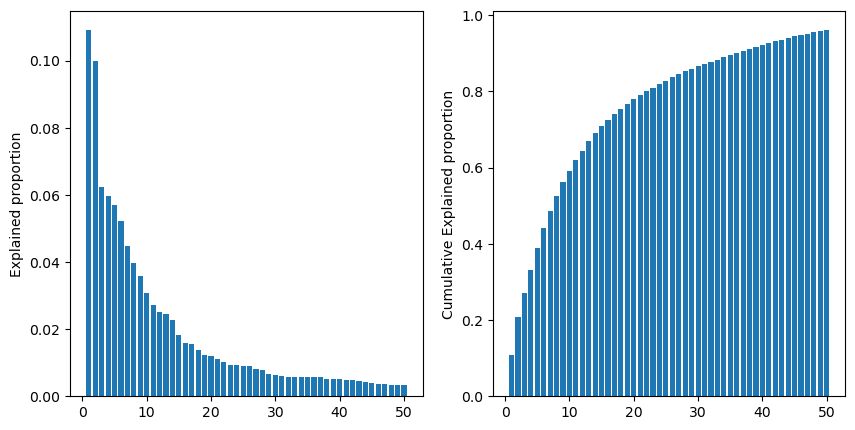

In [46]:
m = pd.read_csv('only_HTF.adjmatrix.tsv', sep='\t', header=0, index_col=0)
A = m.values
n = A.shape[0]
jaccard_D = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        jaccard_D[i, j] = 1 - A[i, j] / (A[i, i] + A[j, j] - A[i, j])
PCoA = pcoa(jaccard_D, dimensions=50)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].bar(range(1, PCoA.proportion_explained.shape[0]+1), PCoA.proportion_explained)
axes[0].set_ylabel('Explained proportion')

axes[1].bar(range(1, PCoA.proportion_explained.shape[0]+1), PCoA.proportion_explained.cumsum())
axes[1].set_ylabel('Cumulative Explained proportion')
plt.savefig(
    "./pdfs/PCoA_contribution.pdf",
    bbox_inches="tight",
    dpi=600
)
plt.show()

## With phylogroups

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


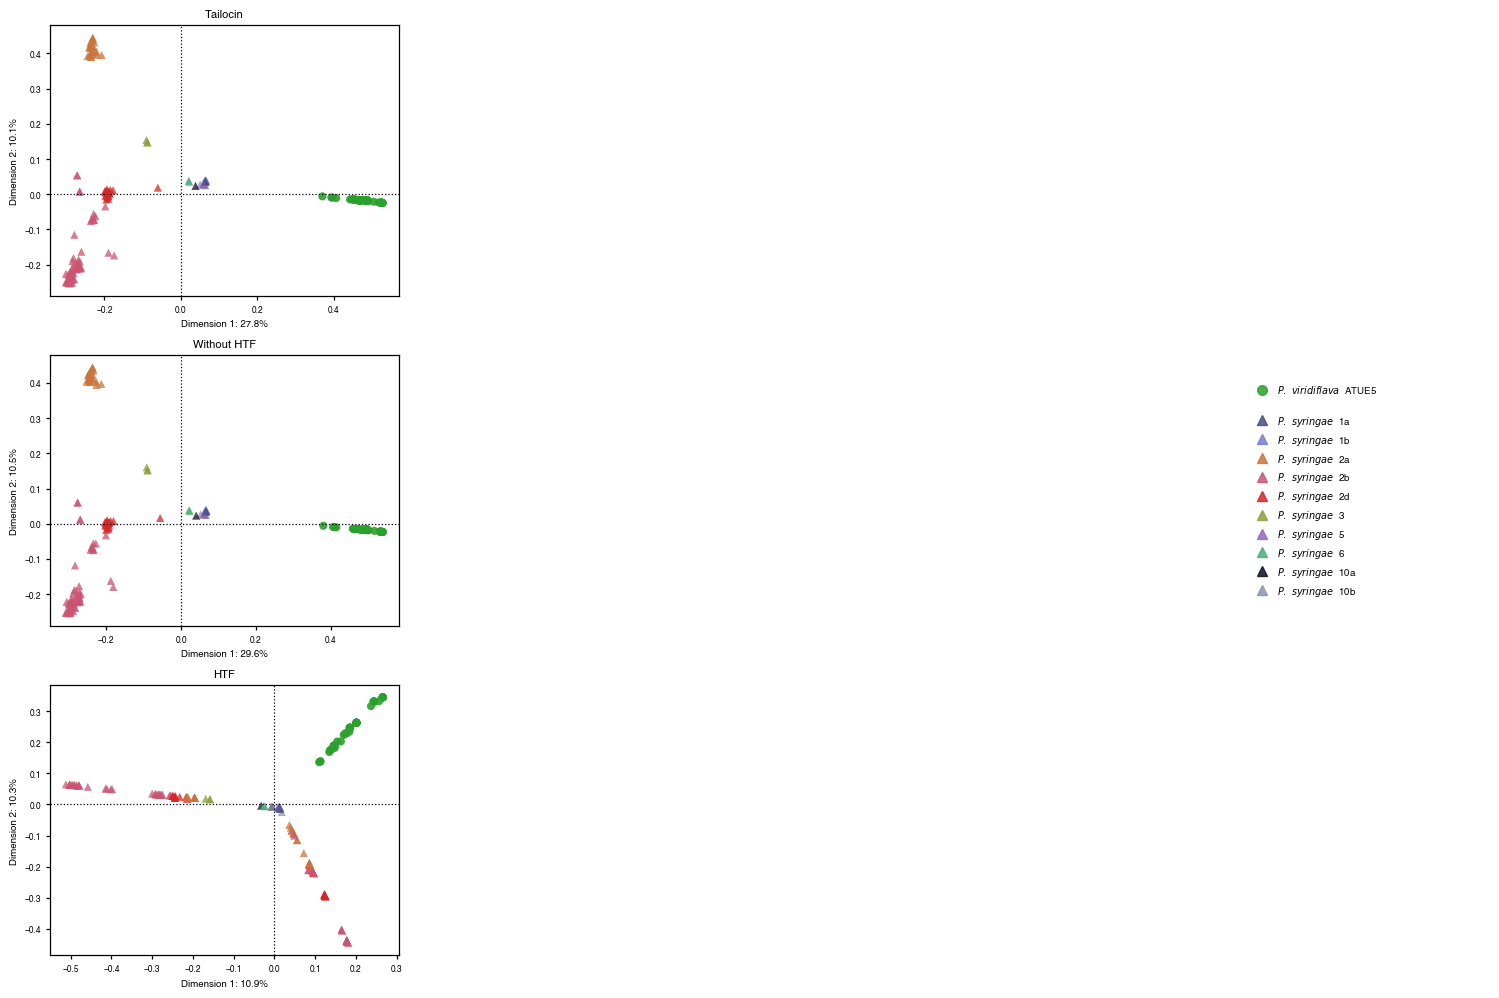

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Saved: final_figs/figS1/FigS1_withoutHTF_D1_D2_phylogroup.pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Saved: final_figs/figS1/FigS1_HTF_D1_D2_phylogroup.pdf


In [18]:

# -----------------------------
# Paths
# -----------------------------
os.chdir("/Users/cuijiajun/Desktop/others/tmphernan/2026_PNAS_revision/results/pankmer")
os.makedirs("./pdfs", exist_ok=True)
os.makedirs("final_figs/figS1", exist_ok=True)

# -----------------------------
# PNAS-like style (match your S2 look)
# Helvetica + 6–9 pt, slightly thicker strokes
# -----------------------------
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Helvetica",
    "font.size": 7,          # within 6–9
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7,

    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
})

# -----------------------------
# Load master metainfo once
# -----------------------------
metainfo_all = pd.read_csv("metainfo/metainfo.ALL.tsv", sep="\t", header=0, index_col=0)
metainfo_all.index = metainfo_all.index.astype(str).str.strip()
metainfo_all["Taxa"] = metainfo_all["Taxa"].astype(str).str.strip()

# -----------------------------
# Color map (phylogroups)
# -----------------------------
phylo_colors = {
    '1a':'#464D86','1b':'#747fca','2a':'#ca743e','2b':'#c95573',
    '2d':'tab:red','3':'#8c9f3e','5':'tab:purple','6':'#4eac7c',
    '10a':'#0F1020','10b':'#8E93B0'
}

# -----------------------------
# Legend (NO refs; species italic)
# -----------------------------
legend_handles = []
legend_handles.append(
    mlines.Line2D([], [], color='tab:green', marker='o', linestyle='None',
                  markersize=7, alpha=0.85,
                  label=r'$\it{P.\ viridiflava}$  ATUE5')
)
legend_handles.append(
    mlines.Line2D([], [], color='None', marker=None, linestyle='None', label='')
)

for l, col in phylo_colors.items():
    legend_handles.append(
        mlines.Line2D([], [], color=col, marker='^', linestyle='None',
                      markersize=7, alpha=0.85,
                      label=rf'$\it{{P.\ syringae}}$  {l}')
    )

# -----------------------------
# Helper: Jaccard distance from intersection/adj matrix
# -----------------------------
def jaccard_distance_from_matrix(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            denom = (A[i, i] + A[j, j] - A[i, j])
            D[i, j] = 0.0 if denom == 0 else (1.0 - A[i, j] / denom)
    return D

# -----------------------------
# Plot ONLY Dimension 1 vs 2
# -----------------------------
def plot_pcoa_dim1_dim2(adj_matrix, title, ax):
    M = pd.read_csv(adj_matrix, sep='\t', header=0, index_col=0)
    cols = M.columns.astype(str)

    meta = metainfo_all.reindex(cols)

    # masks
    mask_psyr = meta["Taxa"].eq("P_syringae").fillna(False).values
    mask_pvir = meta["Taxa"].eq("P_viridiflava").fillna(False).values

    # colors
    psyr_colors = [
        'grey' if (pd.isna(g) or g not in phylo_colors) else phylo_colors[g]
        for g in meta.loc[mask_psyr, "Phylogroup"]
    ]
    pvir_colors = ['tab:green'] * int(mask_pvir.sum())

    # indices
    idx_psyr = np.where(mask_psyr)[0]
    idx_pvir = np.where(mask_pvir)[0]

    # PCoA
    D = jaccard_distance_from_matrix(M.values)
    P = pcoa(D, dimensions=20)

    x, y = 0, 1  # Dimension 1 vs 2

    ax.scatter(P.samples.iloc[idx_psyr, x], P.samples.iloc[idx_psyr, y],
               c=psyr_colors, alpha=0.75, marker='^', s=34, edgecolors='none')

    ax.scatter(P.samples.iloc[idx_pvir, x], P.samples.iloc[idx_pvir, y],
               c=pvir_colors, alpha=0.90, marker='o', s=34, edgecolors='none')

    ax.axvline(0, ls=':', color='black', lw=0.9)
    ax.axhline(0, ls=':', color='black', lw=0.9)

    ax.set_xlabel(f'Dimension 1: {P.proportion_explained.iloc[x]*100:.1f}%')
    ax.set_ylabel(f'Dimension 2: {P.proportion_explained.iloc[y]*100:.1f}%')
    ax.set_title(title)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)

# -----------------------------
# Output 1: Your 3-row overview (D1 vs D2 only) + legend column
# -----------------------------
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

plot_pcoa_dim1_dim2('ALL_genes.adjmatrix.tsv', 'Tailocin', axes[0, 0])
plot_pcoa_dim1_dim2('without_HTF.adjmatrix.tsv', 'Without HTF', axes[1, 0])
plot_pcoa_dim1_dim2('only_HTF.adjmatrix.tsv', 'HTF', axes[2, 0])

# turn off unused axes in columns 2-3 (since we only plot one panel per row now)
for r in range(3):
    for c in (1, 2):
        axes[r, c].axis('off')

# legend column (middle row like before)
axes[0, 3].axis('off')
axes[2, 3].axis('off')
axes[1, 3].axis('off')
axes[1, 3].legend(handles=legend_handles, loc='center', frameon=False,
                  handletextpad=0.6, labelspacing=0.5)

plt.tight_layout()
plt.savefig("./pdfs/PCoA_tailocin_D1D2_withphylogroup_PNASstyle.pdf",
            bbox_inches="tight", dpi=900)
plt.show()

# -----------------------------
# Output 2: FigS1 individual PDFs (WITHOUT HTF + HTF), D1 vs D2 only + legend on right
# Layout: 1×2 (plot + legend column)
# -----------------------------
def save_single_panel_with_legend(adj_matrix, title, out_pdf):
    fig, axarr = plt.subplots(1, 2, figsize=(6.2, 3.2))  # compact, paper-friendly

    plot_pcoa_dim1_dim2(adj_matrix, title, axarr[0])

    axarr[1].axis('off')
    axarr[1].legend(handles=legend_handles, loc='center', frameon=False,
                    handletextpad=0.6, labelspacing=0.5)

    plt.tight_layout()
    fig.savefig(out_pdf, bbox_inches="tight", dpi=900)
    plt.close(fig)
    print("Saved:", out_pdf)

save_single_panel_with_legend(
    "without_HTF.adjmatrix.tsv",
    "Without HTF",
    "final_figs/figS1/FigS1_withoutHTF_D1_D2_phylogroup.pdf"
)

save_single_panel_with_legend(
    "only_HTF.adjmatrix.tsv",
    "HTF",
    "final_figs/figS1/FigS1_HTF_D1_D2_phylogroup.pdf"
)


# NJ trees

Use the jaccard distances to create NJ trees

In [24]:
def nj_tree_from_dist(dist_file):
    dists = pd.read_csv(dist_file, sep='\t', header=0, index_col=0)
    labs = list(dists.columns)
    dists = np.array(dists)
    
    n = dists.shape[0]
    lower_triangular = []
    for i in range(n):
        lower_triangular.append(list(dists[i, :i+1]))
    dm = DistanceMatrix(labs, lower_triangular)

    constructor = DistanceTreeConstructor()
    nj_tree = constructor.nj(dm)
    return nj_tree

In [25]:
tree = nj_tree_from_dist('ALL_genes.distance.jaccard.tsv')
Phylo.write(tree, './NJ_trees/ALL_genes.distance.jaccard.NJ.newick', format='newick')

tree = nj_tree_from_dist('without_HTF.distance.jaccard.tsv')
Phylo.write(tree, './NJ_trees/without_HTF.distance.jaccard.NJ.newick', format='newick')

tree = nj_tree_from_dist('only_HTF.distance.jaccard.tsv')
Phylo.write(tree, './NJ_trees/only_HTF.distance.jaccard.NJ.newick', format='newick')

1

###Run visualization of NJ trees

In [49]:
#!/usr/bin/env python3
import os
import math
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Patch
from matplotlib.colors import to_rgb
from Bio import Phylo

# -----------------------------
# PNAS-like style (7 pt)
# -----------------------------
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Helvetica",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
})

# -----------------------------
# Load metadata (match your PCoA IDs)
# -----------------------------
meta = pd.read_csv("metainfo/metainfo.ALL.tsv", sep="\t", index_col=0)
meta.index = meta.index.astype(str).str.strip()
meta["Taxa"] = meta["Taxa"].astype(str).str.strip()

# -----------------------------
# Palettes (unchanged)
# -----------------------------
tailocin_type_colors = {'T1': 'tab:green', 'T2': 'tab:purple'}
length_colors = {1245: 'yellow', 1803: 'tab:red', 1383: 'tab:blue', 1830: 'tab:pink'}
phylo_colors = {
    '1a': '#464D86', '1b': '#747fca', '2a': '#ca743e', '2b': '#c95573', '2d': 'tab:red',
    '3': '#8c9f3e', '5': 'tab:purple', '6': '#4eac7c', '10a': '#0F1020', '10b': '#8E93B0'
}

# -----------------------------
# Helpers
# -----------------------------
def norm_name(x: str) -> str:
    if x is None:
        return ""
    x = str(x).strip()
    if (x.startswith("'") and x.endswith("'")) or (x.startswith('"') and x.endswith('"')):
        x = x[1:-1]
    return x.strip()

meta_idx_norm = {norm_name(i): i for i in meta.index}

def meta_row_for_tip(tip_name: str):
    k = norm_name(tip_name)
    if k in meta.index:
        return meta.loc[k], k, True
    if k in meta_idx_norm:
        real = meta_idx_norm[k]
        return meta.loc[real], real, True
    return None, k, False

def get_col(row, *cands, default=np.nan):
    for c in cands:
        if c in row.index:
            return row[c]
    return default

def blend_with_white(color, alpha=0.75):
    r, g, b = to_rgb(color)
    rr = r*(1-alpha) + 1*alpha
    gg = g*(1-alpha) + 1*alpha
    bb = b*(1-alpha) + 1*alpha
    return (rr, gg, bb)

def stable_pastel_color(name: str, palette="tab20", alpha=0.60):
    cmap = plt.get_cmap(palette)
    n = cmap.N
    h = int(hashlib.md5(name.encode("utf-8")).hexdigest(), 16)
    base = cmap(h % n)
    r, g, b, _ = base
    return (r*(1-alpha)+alpha, g*(1-alpha)+alpha, b*(1-alpha)+alpha)

def is_ATUE5(row, ok: bool) -> bool:
    """
    Robust ATUE5 flag: Taxa == P_viridiflava (strip whitespace).
    """
    if not ok or row is None:
        return False
    taxa = get_col(row, "Taxa", "taxa", default=np.nan)
    return (not pd.isna(taxa)) and (str(taxa).strip() == "P_viridiflava")

# -----------------------------
# Layout: unrooted radial coords
# (minimal change: start_angle support)
# -----------------------------
def compute_unrooted_radial_layout(tree, start_angle=90.0):
    """
    Planar unrooted radial layout for NJ trees.
    Key fixes vs your current version:
      1) tips get angles in a *planar leaf order* (reduces crossings)
      2) internal node angle uses *circular mean* (handles 0/360 wrap)
    Returns coords dict: clade -> (x, y, radius, theta_deg)
    """
    tree.ladderize(reverse=True)

    def leaf_order(clade):
        if clade.is_terminal():
            return [clade]
        out = []
        for ch in clade.clades:
            out.extend(leaf_order(ch))
        return out

    terminals = leaf_order(tree.root)
    n = len(terminals)

    tip_angles = {}
    for i, tip in enumerate(terminals):
        theta = (start_angle + 360.0 * i / max(1, n)) % 360.0
        tip_angles[tip] = theta

    node_angles = {}

    def circ_mean_deg(degs):
        rads = np.deg2rad(degs)
        s = np.mean(np.sin(rads))
        c = np.mean(np.cos(rads))
        ang = np.arctan2(s, c)
        deg = (np.rad2deg(ang)) % 360.0
        return deg

    def assign_angles(clade):
        if clade in tip_angles:
            node_angles[clade] = tip_angles[clade]
            return tip_angles[clade]
        child_angles = [assign_angles(c) for c in clade.clades]
        node_angles[clade] = circ_mean_deg(child_angles)
        return node_angles[clade]

    assign_angles(tree.root)

    depths = tree.depths()
    max_depth = max(depths.values()) if depths else 1.0

    coords = {}
    for clade, depth in depths.items():
        r = (depth / max_depth) ** 0.65
        theta_deg = node_angles.get(clade, 0.0)
        theta_rad = math.radians(theta_deg)
        x = r * math.cos(theta_rad)
        y = r * math.sin(theta_rad)
        coords[clade] = (x, y, r, theta_deg)

    return coords, terminals

# -----------------------------
# Ring colors by feature
# -----------------------------
def color_phylogroup(tipname, row):
    taxa = get_col(row, "Taxa", "taxa", default=np.nan)
    if taxa == "P_syringae":
        pg = get_col(row, "Phylogroup", "phylogroup", default=np.nan)
        pg = None if pd.isna(pg) else str(pg)
        return phylo_colors.get(pg, "0.9")
    elif taxa == "P_viridiflava":
        return "tab:green"
    return "0.9"

def color_tailocin_type(tipname, row):
    taxa = get_col(row, "Taxa", "taxa", default=np.nan)
    if taxa == "P_syringae":
        tt = get_col(row, "Tailocin_type", "tailocin_type", default=np.nan)
        tt = None if pd.isna(tt) else str(tt)
        return tailocin_type_colors.get(tt, "0.9")
    elif taxa == "P_viridiflava":
        return tailocin_type_colors["T1"]  # forced T1 for ATUE5
    return "0.9"

def color_htf_length(tipname, row):
    taxa = get_col(row, "Taxa", "taxa", default=np.nan)

    if taxa == "P_viridiflava":
        L = get_col(row, "HTF_length", "htf_length", "HTF_len", default=np.nan)
        try:
            L = int(L)
        except Exception:
            L = None
        return length_colors.get(L, "0.9")

    if taxa == "P_syringae":
        return stable_pastel_color(norm_name(tipname), palette="tab20", alpha=0.60)

    return "0.9"

# -----------------------------
# Plot function (NO tip labels)
# NOTE: NO ATUE5 outline here (so all other trees stay unchanged)

def plot_circular_tree_with_rings(
    newick_file: str,
    out_pdf: str,
    title: str = None,
    rings=("phylogroup",),
    branch_color="0.25",
    branch_lw=0.85,
    start_angle=90.0,
    rings_start=1.03,
    ring_width=0.040,
    ring_gap=0.010,
    dashed_extend=True,
    dash_color="0.55",
    dash_lw=0.75,
    dash_style=(0, (2.5, 2.5)),
    # ---- NEW: enable outline only when requested ----
    highlight_atue5=False,
    atue5_outline_lw=0.35,
):
    tree = Phylo.read(newick_file, "newick")
    coords, terminals = compute_unrooted_radial_layout(tree, start_angle=start_angle)

    out_dir = os.path.dirname(out_pdf)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    fig = plt.figure(figsize=(6.3, 5.6))
    ax = fig.add_subplot(111)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.subplots_adjust(right=0.78)

    # ---- branches: arc + radial ----
    for parent in tree.find_clades(order="preorder"):
        _, _, r0, th0_deg = coords[parent]
        th0 = math.radians(th0_deg)

        for child in parent.clades:
            _, _, r1, th1_deg = coords[child]
            d = (th1_deg - th0_deg + 180.0) % 360.0 - 180.0
            th1_deg_wrapped = th0_deg + d
            th1 = math.radians(th1_deg_wrapped)

            ths = np.linspace(th0, th1, 30)
            ax.plot(r0*np.cos(ths), r0*np.sin(ths),
                    color=branch_color, lw=branch_lw, zorder=1)

            rs = np.linspace(r0, r1, 12)
            ax.plot(rs*np.cos(th1), rs*np.sin(th1),
                    color=branch_color, lw=branch_lw, zorder=1)

    # ---- ring radii ----
    ring_bounds = []
    r_in = rings_start
    for _ in rings:
        r_out = r_in + ring_width
        ring_bounds.append((r_in, r_out))
        r_in = r_out + ring_gap

    r_target = ring_bounds[0][0] if ring_bounds else rings_start

    # ---- wedge span per tip ----
    n = len(terminals)
    full_span = 360.0 / max(1, n)
    span = full_span * 0.985
    pad = (full_span - span) / 2.0

    unmatched = []

    # ---- dashed extensions + wedges ----
    for tip in terminals:
        tipname = tip.name
        row, _, ok = meta_row_for_tip(tipname)
        atue5 = is_ATUE5(row, ok)

        _, _, r_tip, th_deg = coords[tip]
        th = math.radians(th_deg)

        if dashed_extend and r_tip < r_target:
            rs = np.linspace(r_tip, r_target, 30)
            ax.plot(rs*np.cos(th), rs*np.sin(th),
                    color=dash_color, lw=dash_lw, linestyle=dash_style, zorder=2)

        a1 = th_deg - span/2.0 + pad
        a2 = th_deg + span/2.0 - pad

        if not ok:
            unmatched.append(tipname)
            color_map = {"htf": "0.9", "type": "0.9", "phylogroup": "0.9"}
        else:
            color_map = {
                "htf": color_htf_length(tipname, row),
                "type": color_tailocin_type(tipname, row),
                "phylogroup": color_phylogroup(tipname, row),
            }

        for (rin, rout), feat in zip(ring_bounds, rings):
            face = color_map.get(feat, "0.9")

            # ---- fill wedge ----
            ax.add_patch(Wedge(
                (0, 0), rout, a1, a2,
                width=(rout - rin),
                facecolor=face,
                edgecolor="none",
                zorder=5
            ))

            # ---- ATUE5 outline ONLY when requested, and only on the 'type' ring ----
            if highlight_atue5 and atue5 and feat == "type":
                ax.add_patch(Wedge(
                    (0, 0), rout, a1, a2,
                    width=(rout - rin),
                    facecolor="none",
                    edgecolor="black",
                    linewidth=atue5_outline_lw,
                    joinstyle="miter",
                    capstyle="butt",
                    antialiased=True,
                    zorder=6
                ))

    # -----------------------------
    # Legends
    # -----------------------------
    extra_artists = []
    y_top = 1.00

    tip_rows = []
    for tip in terminals:
        row, _, ok = meta_row_for_tip(tip.name)
        if ok:
            tip_rows.append(row)

    def has_na_in_ring(feat: str) -> bool:
        if not tip_rows:
            return False
        if feat == "phylogroup":
            for r in tip_rows:
                if get_col(r, "Taxa", default="") == "P_syringae":
                    v = get_col(r, "Phylogroup", default=np.nan)
                    if pd.isna(v) or (str(v) not in phylo_colors):
                        return True
            return False
        if feat == "type":
            for r in tip_rows:
                if get_col(r, "Taxa", default="") == "P_syringae":
                    v = get_col(r, "Tailocin_type", default=np.nan)
                    if pd.isna(v) or (str(v) not in tailocin_type_colors):
                        return True
            return False
        return False

    def add_legend(handles, title, y_top):
        leg = ax.legend(
            handles=handles,
            title=title,
            loc="upper left",
            bbox_to_anchor=(1.02, y_top),
            frameon=False,
            labelspacing=0.30,
            handlelength=1.0,
            handletextpad=0.6,
            borderaxespad=0.0
        )
        leg._legend_box.align = "left"
        leg.get_title().set_ha("left")
        ax.add_artist(leg)
        extra_artists.append(leg)
        return leg

    # ----- phylogroup legend -----
    if "phylogroup" in rings:
        pg_order = ["1a", "1b", "2a", "2b", "2d", "3", "5", "6", "10a", "10b"]
        handles = []

        handles.append(Patch(facecolor="tab:green", edgecolor="none",
                             label=r"$\it{P.\ viridiflava}$  ATUE5"))

        for g in pg_order:
            if g in phylo_colors:
                handles.append(Patch(facecolor=phylo_colors[g], edgecolor="none",
                                     label=rf"$\it{{P.\ syringae}}$  {g}"))

        if has_na_in_ring("phylogroup"):
            handles.append(Patch(facecolor="0.9", edgecolor="none",
                                 label=" NA"))

        add_legend(handles, title="Ring: phylogroup", y_top=y_top)

    # ----- type legend (UPDATED when highlight_atue5=True) -----
    if "type" in rings:
        handles = [
            Patch(facecolor=tailocin_type_colors["T1"], edgecolor="none", label=r"$\it{P.\ syringae}$ T1"),
            Patch(facecolor=tailocin_type_colors["T2"], edgecolor="none", label=r"$\it{P.\ syringae}$ T2"),
        ]

        if highlight_atue5:
            handles.append(Patch(
                facecolor=tailocin_type_colors["T1"],
                edgecolor="black",
                linewidth=atue5_outline_lw,
                label=r"$\it{P.\ viridiflava}$ ATUE5 T1"
            ))
        else:
            handles.append(Patch(
                facecolor=tailocin_type_colors["T1"],
                edgecolor="none",
                label=r"$\it{P.\ viridiflava}$ ATUE5 T1"
            ))

        if has_na_in_ring("type"):
            handles.append(Patch(facecolor="0.9", edgecolor="none", label="NA"))

        add_legend(handles, title="Ring: tail fiber type", y_top=y_top)

    if title:
        ax.set_title(title, y=1.02)

    plt.savefig(out_pdf, bbox_inches="tight", bbox_extra_artists=extra_artists)
    plt.close(fig)

    if unmatched:
        print(f"[WARN] {len(unmatched)} tips not found in metadata (first 20):")
        for x in unmatched[:20]:
            print("  ", x)

# -----------------------------
# Make 4 panels (no labels)
# -----------------------------
nwk_without = "./NJ_trees/without_HTF.distance.jaccard.NJ.newick"
nwk_onlyhtf = "./NJ_trees/only_HTF.distance.jaccard.NJ.newick"

plot_circular_tree_with_rings(
    newick_file=nwk_without,
    out_pdf="final_figs/figS1/withoutHTF.circular.phylogroup.pdf",
    title="Without HTF (NJ) — phylogroup",
    rings=("phylogroup",),
    dashed_extend=True
)
plot_circular_tree_with_rings(
    newick_file=nwk_onlyhtf,
    out_pdf="final_figs/figS1/onlyHTF.circular.phylogroup.pdf",
    title="Only HTF (NJ) — phylogroup",
    rings=("phylogroup",),
    dashed_extend=True
)

plot_circular_tree_with_rings(
    newick_file=nwk_without,
    out_pdf="final_figs/figS2/withoutHTF.circular.type.pdf",
    title="Without HTF (NJ) — tail fiber type",
    rings=("type",),
    highlight_atue5=True,
    dashed_extend=True
)

plot_circular_tree_with_rings(
    newick_file=nwk_onlyhtf,
    out_pdf="final_figs/figS2/onlyHTF.circular.type.pdf",
    title="Only HTF (NJ) — tail fiber type",
    rings=("type",),
    dashed_extend=True,
    highlight_atue5=True,
    atue5_outline_lw=0.35
)

print("[DONE] 4 PDFs -> final_figs/figS1 and final_figs/figS2")


# ================================
# APPEND THIS BLOCK AT THE END
# (adds ONE extra output: only_HTF tree, 1 ring = type, WITH tip labels)
# ONLY HERE: ATUE5 thin black outline + legend updated
# ================================
def plot_onlyHTF_type_with_labels(
    newick_file: str,
    out_pdf: str,
    title: str = "Only HTF (NJ) — tail fiber type (labeled)",
    branch_color="0.25",
    branch_lw=0.85,
    start_angle=90.0,
    rings_start=1.10,
    ring_width=0.050,
    dashed_extend=True,
    dash_color="0.55",
    dash_lw=0.75,
    dash_style=(0, (2.5, 2.5)),
    label_offset=0.16,
    label_fontsize=5.2,
    atue5_outline_lw=0.35,   # <-- thin outline (0.35–0.5 is usually best in PDF)
):
    tree = Phylo.read(newick_file, "newick")
    coords, terminals = compute_unrooted_radial_layout(tree, start_angle=start_angle)

    os.makedirs(os.path.dirname(out_pdf), exist_ok=True)

    fig = plt.figure(figsize=(9.2, 8.0))
    ax = fig.add_subplot(111)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.subplots_adjust(left=0.02, right=0.78)

    # ---- branches ----
    for parent in tree.find_clades(order="preorder"):
        _, _, r0, th0_deg = coords[parent]
        th0 = math.radians(th0_deg)

        for child in parent.clades:
            _, _, r1, th1_deg = coords[child]
            d = (th1_deg - th0_deg + 180.0) % 360.0 - 180.0
            th1_deg_wrapped = th0_deg + d
            th1 = math.radians(th1_deg_wrapped)

            ths = np.linspace(th0, th1, 30)
            ax.plot(r0*np.cos(ths), r0*np.sin(ths),
                    color=branch_color, lw=branch_lw, zorder=1)

            rs = np.linspace(r0, r1, 12)
            ax.plot(rs*np.cos(th1), rs*np.sin(th1),
                    color=branch_color, lw=branch_lw, zorder=1)

    # ---- ring bounds ----
    r_in = rings_start
    r_out = r_in + ring_width
    r_target = r_in

    n = len(terminals)
    full_span = 360.0 / max(1, n)
    span = full_span * 0.985
    pad = (full_span - span) / 2.0

    # ---- wedges + labels ----
    for tip in terminals:
        tipname = tip.name
        row, _, ok = meta_row_for_tip(tipname)
        atue5 = is_ATUE5(row, ok)

        _, _, r_tip, th_deg = coords[tip]
        th = math.radians(th_deg)

        if dashed_extend and r_tip < r_target:
            rs = np.linspace(r_tip, r_target, 30)
            ax.plot(rs*np.cos(th), rs*np.sin(th),
                    color=dash_color, lw=dash_lw, linestyle=dash_style, zorder=2)

        a1 = th_deg - span/2.0 + pad
        a2 = th_deg + span/2.0 - pad

        face = color_tailocin_type(tipname, row) if ok else "0.9"

        # ---- fill wedge ----
        ax.add_patch(Wedge(
            (0, 0), r_out, a1, a2,
            width=(r_out - r_in),
            facecolor=face,
            edgecolor="none",
            zorder=5
        ))

        # ---- ATUE5 thin outline on top ----
        if atue5:
            ax.add_patch(Wedge(
                (0, 0), r_out, a1, a2,
                width=(r_out - r_in),
                facecolor="none",
                edgecolor="black",
                linewidth=atue5_outline_lw,
                joinstyle="miter",
                capstyle="butt",
                antialiased=True,
                zorder=6
            ))

        # ---- labels ----
        label_r = r_out + label_offset
        x = label_r * math.cos(th)
        y = label_r * math.sin(th)

        rot = th_deg
        if rot > 90:
            rot -= 180
        if rot < -90:
            rot += 180

        ha = "left" if -90 <= th_deg <= 90 else "right"

        ax.text(
            x, y, norm_name(tipname),
            rotation=rot,
            rotation_mode="anchor",
            ha=ha, va="center",
            fontsize=label_fontsize
        )

    # ---- legend (UPDATED: ATUE5 patch has black outline) ----
    handles = [
        Patch(facecolor=tailocin_type_colors["T1"], edgecolor="none", label="T1"),
        Patch(facecolor=tailocin_type_colors["T2"], edgecolor="none", label="T2"),
        Patch(
            facecolor=tailocin_type_colors["T1"],
            edgecolor="black",
            linewidth=atue5_outline_lw,
            label=r"$\it{Pseudomonas\ viridiflava}$ (ATUE5)"
        ),
    ]
    leg = ax.legend(
        handles=handles,
        title="Ring: tail fiber type",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=False
    )
    ax.add_artist(leg)

    ax.set_title(title, y=1.02)
    plt.savefig(out_pdf, bbox_inches="tight", dpi=600)
    plt.close()

# ---- call it (ONLY this output gets ATUE5 outline + legend update) ----
plot_onlyHTF_type_with_labels(
    newick_file="./NJ_trees/only_HTF.distance.jaccard.NJ.newick",
    out_pdf="final_figs/figS2/onlyHTF.circular.type.labeled.pdf",
    title="Only HTF (NJ) — tail fiber type (labeled)",
    atue5_outline_lw=0.35
)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


[DONE] 4 PDFs -> final_figs/figS1 and final_figs/figS2


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


unrooted plain tree in R 